In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, inv
from scipy.linalg import pinv
from numba import njit
import numpy as np

In [2]:
def compute_covariance(X0):
    return np.cov(X0, rowvar=False)

from scipy.stats import pearsonr, spearmanr
import numpy as np

def compute_pearson_correlation_matrix(X):
    """
    Compute pairwise Pearson correlation coefficients between columns of X.

    Parameters:
        X (ndarray): shape (n_samples, n_features)

    Returns:
        corr_matrix (ndarray): shape (n_features, n_features)
    """
    n_features = X.shape[1]
    corr_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                corr_matrix[i, j] = 1.0
            else:
                corr, _ = pearsonr(X[:, i], X[:, j])
                corr_matrix[i, j] = corr

    return corr_matrix


In [3]:
def compute_gene_difference_covariance(x1_all, x2_all, time_index, twin=True):
    """
    Computes the covariance matrix of gene-wise differences between twin simulations
    (or between randomly paired cells if twin=False).

    Parameters
    ----------
    x1_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 1.
    x2_all : ndarray, shape (n_cells, n_timepoints, n_genes)
        Simulation results for twin 2.
    time_index : int
        Time point at which to compute differences.
    twin : bool, default=True
        If True, compares twins directly.
        If False, compares random pairs (shuffles x1 before differencing).

    Returns
    -------
    cov_matrix : ndarray, shape (n_genes, n_genes)
        Covariance matrix of gene-wise differences (x1 - x2).
    """
    # Get values at the given time point
    x1_t = x1_all[:, time_index, :]
    x2_t = x2_all[:, time_index, :]

    # Compute differences
    if not twin:
        x1_t = np.random.permutation(x1_t)  # shuffle x1 across cells

    diffs = x1_t - x2_t  # shape: (n_cells, n_genes)

    # Covariance of differences
    return compute_pearson_correlation_matrix(diffs)



In [ ]:
# Parameters
N = 2
T = 30
dt = 0.05
timesteps = int(T / dt)
lambda_base = 1.0
D = 0.5
epsilon = 1/(N)**.5*(1.-.05)  # subcritical but close to transition
# epsilon = 1/(N)**.5  # subcritical but close to transition
# epsilon = 1/(N)**.5*(1.+.05)  # subcritical but close to transition
np.random.seed(42)
K = np.random.normal(0, 1.0, size=(N, N)) - 1
# K = np.zeros(shape=(N, N))
# K = (K + K.T) / 2  # symmetrize
np.fill_diagonal(K, 0)
A = lambda_base * np.eye(N) + epsilon * K

# Compute the smallest real part of the eigenvalues of A
eigvals = np.linalg.eigvals(A)
lambda_min = np.min(np.real(eigvals))

# Estimate relaxation time
relax_time = 10 / lambda_min  # heuristic: ~5 relaxation times to reach steady state
# T = relax_time
# timesteps = int(T/dt)
print(f"Minimum eigenvalue of A (Re part): {lambda_min:.4f}")
print(f"Recommended minimum simulation time for relaxation: T ≳ {relax_time:.2f}")

@njit(fastmath=True)
def simulate_ou(A, u, with_input, timesteps, N, D, dt, x0=None):
    x = np.zeros((timesteps, N))
    
    # Set initial condition
    if x0 is not None:
        x[0] = x0

    sqrt_2Ddt = np.sqrt(2 * D * dt)
    zero_vec = np.zeros(N)
    force = u if with_input else zero_vec

    for t in range(1, timesteps):
        noise = np.random.normal(0.0, 1.0, N)
        dx = (-A @ x[t - 1] + force) * dt + sqrt_2Ddt * noise
        x[t] = x[t - 1] + dx

    return x


n_cells = 10000  # number of samples
samples = np.zeros((n_cells, N))

# Step 1: Draw initial states from some distribution (e.g., steady state OU)
for i in range(n_cells):
    x = simulate_ou(A, u, False, timesteps, N, D, dt)
    samples[i] = x[-1]  # Use final state as steady-state sample

# Step 2: Simulate twins starting from the same initial state
x1_all = np.zeros((n_cells, timesteps, N))
x2_all = np.zeros((n_cells, timesteps, N))

for i in range(n_cells):
    x0 = samples[i]
    x1_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)
    x2_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)

In [20]:
# Get values at time index 10 for all cells
x1_t10 = x1_all[:, 10, :]  # shape: (n_cells, N)
x2_t10 = x2_all[:, 10, :]  # shape: (n_cells, N)

# Concatenate x1_t10 and x2_t10 along the last axis
x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)

cov = compute_covariance(x_combined)
cov

array([[0.67476923, 0.30718291],
       [0.30718291, 0.60442411]])

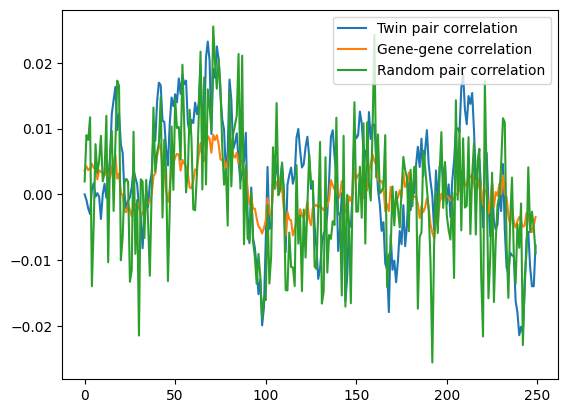

In [38]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 30/0.05, 0.1/0.05)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()

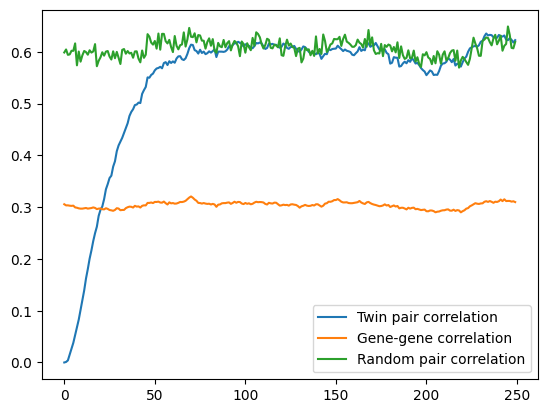

In [40]:
twin_pair_correlation = []
gene_gene_correlation = []
random_pair_correlation = []
time_points = np.arange(0, 250)
for time in time_points:
    x1_at_time = x1_all[:, time, :]  # shape: (n_cells, N)
    x2_at_time = x2_all[:, time, :]  # shape: (n_cells, N)
    x_combined = np.concatenate((x1_at_time, x2_at_time), axis=0)  # shape: (n_cells, 2 * N)
    cov = compute_covariance(x_combined)[0, 1]
    gene_gene_correlation.append(cov)
    # Concatenate x1_t10 and x2_t10 along the last axis
    x_combined = np.concatenate((x1_t10, x2_t10), axis=0)  # shape: (n_cells, 2 * N)
    twin_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)[0, 1])
    random_pair_correlation.append(compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)[0, 1])

plt.plot(time_points, twin_pair_correlation, label = "Twin pair correlation")
plt.plot(time_points, gene_gene_correlation, label = "Gene-gene correlation")
plt.plot(time_points, random_pair_correlation, label = "Random pair correlation")
plt.legend()
plt.show()

# Linear cascade of 3 genes


In [4]:
# Parameters
N = 3
T = 300
dt = 0.05
timesteps = int(T / dt)
lambda_base = 1.0
D = 0.05
# epsilon = 1/(N)**.5*(1.-.05)  # subcritical but close to transition
# # epsilon = 1/(N)**.5  # subcritical but close to transition
# # epsilon = 1/(N)**.5*(1.+.05)  # subcritical but close to transition
# np.random.seed(42)
# K = np.random.normal(0, 1.0, size=(N, N)) - 1
# # K = np.zeros(shape=(N, N))
# # K = (K + K.T) / 2  # symmetrize
# np.fill_diagonal(K, 0)
# A = lambda_base * np.eye(N) + epsilon * K
A = np.array([[1, -0.0, -0.0], [-5, 1, -0.0], [-0, -5.0, 1]])
# Compute the smallest real part of the eigenvalues of A
eigvals = np.linalg.eigvals(A)
lambda_min = np.min(np.real(eigvals))

# Estimate relaxation time
relax_time = 10 / lambda_min  # heuristic: ~5 relaxation times to reach steady state
# T = relax_time
# timesteps = int(T/dt)
print(f"Minimum eigenvalue of A (Re part): {lambda_min:.4f}")
print(f"Recommended minimum simulation time for relaxation: T ≳ {relax_time:.2f}")
u = np.zeros(N)
@njit(fastmath=True)
def simulate_ou(A, u, with_input, timesteps, N, D, dt, x0=None):
    x = np.zeros((timesteps, N))
    
    # Set initial condition
    if x0 is not None:
        x[0] = x0

    sqrt_2Ddt = np.sqrt(2 * D * dt)
    zero_vec = np.zeros(N)
    force = u if with_input else zero_vec

    for t in range(1, timesteps):
        noise = np.random.normal(0.0, 1.0, N)
        dx = (-A @ x[t - 1] + force) * dt + sqrt_2Ddt * noise
        x[t] = x[t - 1] + dx

    return x


n_cells = 10000  # number of samples
samples = np.ones((n_cells, N)) 

# Step 1: Draw initial states from some distribution (e.g., steady state OU)
for i in range(n_cells):
    x = simulate_ou(A, u, False, timesteps, N, D, dt)
    samples[i] = x[-1]  # Use final state as steady-state sample

# Step 2: Simulate twins starting from the same initial state
x1_all = np.zeros((n_cells, timesteps, N))
x2_all = np.zeros((n_cells, timesteps, N))

for i in range(n_cells):
    x0 = samples[i]
    x1_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)
    x2_all[i] = simulate_ou(A, u, False, timesteps, N, D, dt, x0=x0)

Minimum eigenvalue of A (Re part): 1.0000
Recommended minimum simulation time for relaxation: T ≳ 10.00


/home/mzo5929/.conda/envs/grnSimulationQuest/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


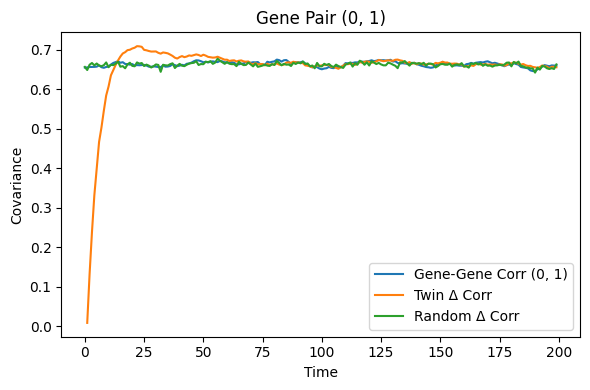

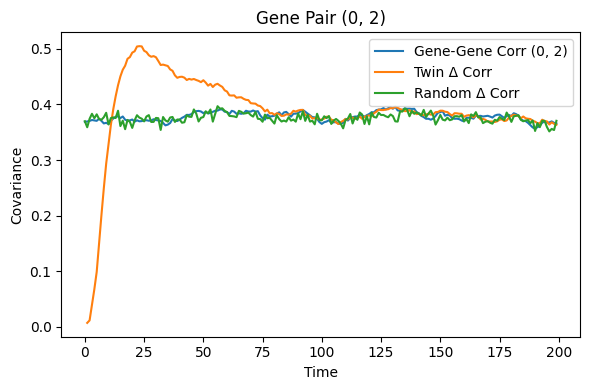

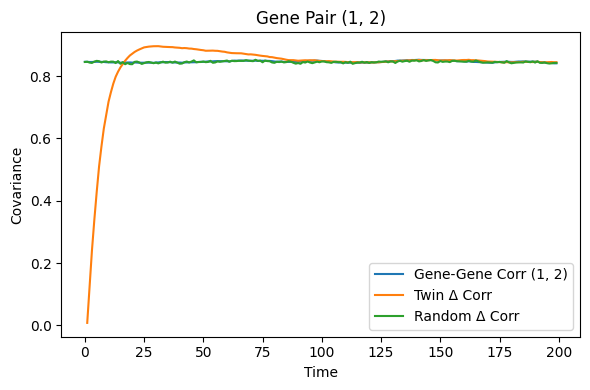

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations, permutations

# Initialize dictionary to store per-pair time series
twin_pair_correlation = {}
gene_gene_correlation = {}
random_pair_correlation = {}

n_genes = x1_all.shape[2]
time_points = np.arange(x1_all.shape[1])[:200:1]

# Initialize empty time series for each gene pair
gene_pairs = list(combinations(range(n_genes), 2))
for i, j in gene_pairs:
    twin_pair_correlation[(i, j)] = []
    gene_gene_correlation[(i, j)] = []
    random_pair_correlation[(i, j)] = []

for time in time_points:
    x1_at_time = x1_all[:, time, :]  # (n_cells, n_genes)
    x2_at_time = x2_all[:, time, :]  # (n_cells, n_genes)
    x_combined = x1_at_time

    # Gene-gene correlation matrix
    cov_expr = compute_pearson_correlation_matrix(x_combined)
    cov_twin = compute_gene_difference_covariance(x1_all, x2_all, time, twin=True)
    cov_random = compute_gene_difference_covariance(x1_all, x2_all, time, twin=False)

    for i, j in gene_pairs:
        gene_gene_correlation[(i, j)].append(cov_expr[i, j])
        twin_pair_correlation[(i, j)].append(cov_twin[i, j])
        random_pair_correlation[(i, j)].append(cov_random[i, j])

for i, j in gene_pairs:
    plt.figure(figsize=(6, 4))
    plt.plot(time_points, gene_gene_correlation[(i, j)], label=f"Gene-Gene Corr ({i}, {j})")
    plt.plot(time_points, twin_pair_correlation[(i, j)], label="Twin Δ Corr")
    plt.plot(time_points, random_pair_correlation[(i, j)], label="Random Δ Corr")
    plt.xlabel("Time")
    plt.ylabel("Covariance")
    plt.title(f"Gene Pair ({i}, {j})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
x1_all_t1 = x1_all[:, int(5/0.05), :]
x2_all_t2 = x2_all[:, int(5/0.05), :]

x_all_time = np.concatenate((x1_all_t1, x2_all_t2), axis=0)
np.savetxt("/home/mzo5929/Keerthana/grnInference/code/grnInferenceRepo/analysis_code/test_PID_julia/x_combined_fan_out_4.csv", x_all_time, delimiter=",")


0 0


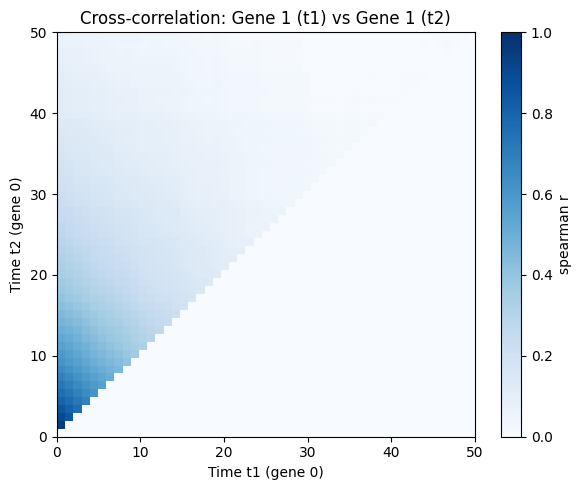

0 1


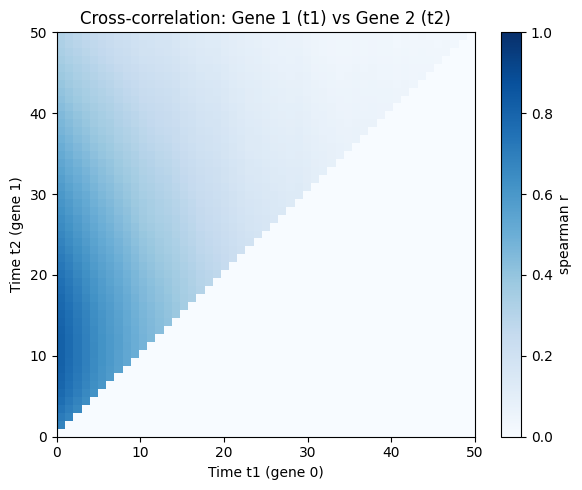

0 2


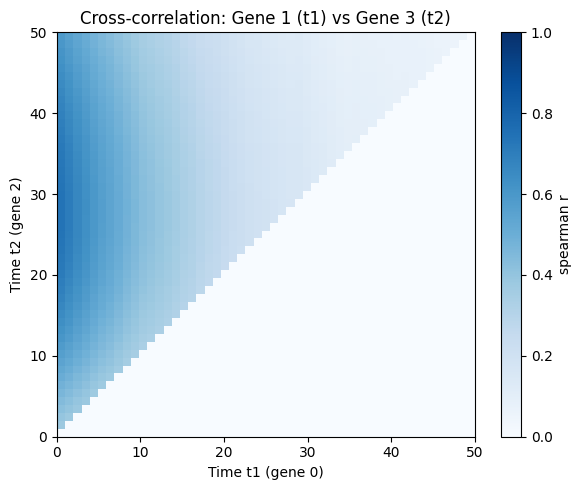

1 0


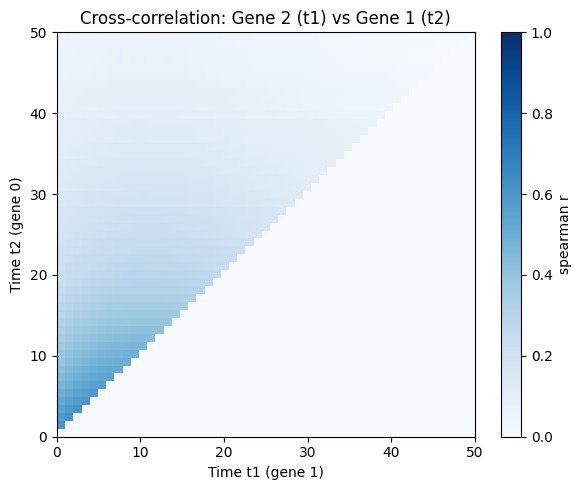

1 1


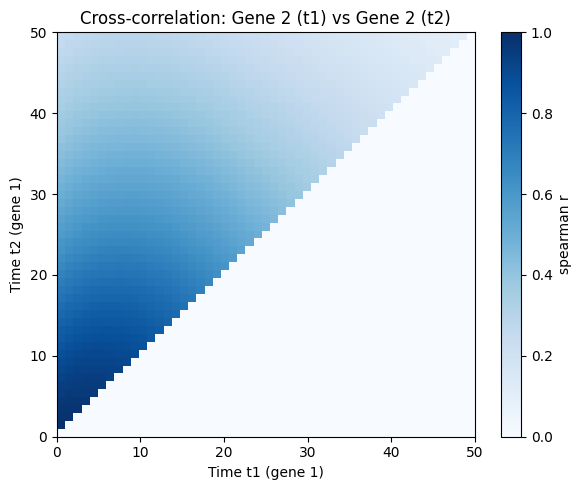

1 2


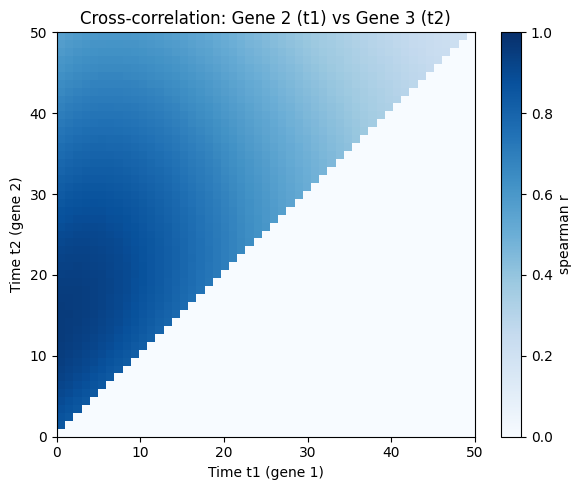

2 0


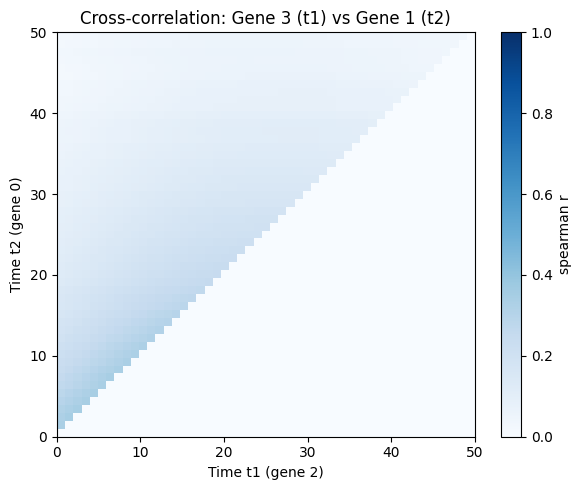

2 1


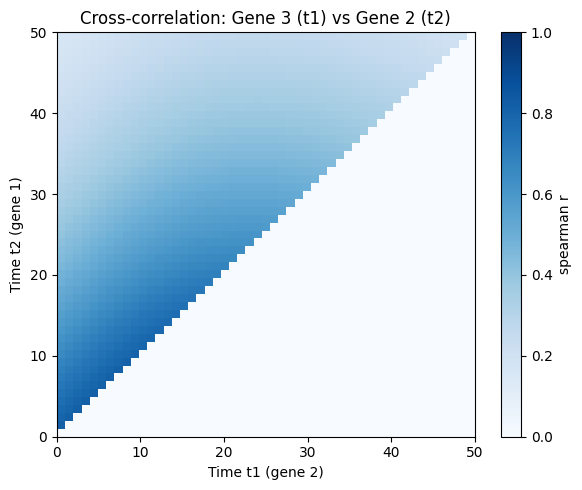

2 2


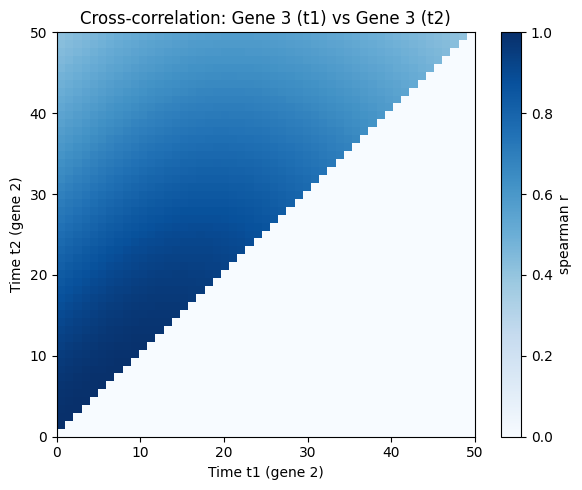

In [6]:
from scipy.stats import pearsonr, spearmanr

def compute_cross_correlation_matrix(x1_all, x2_all, gene_i, gene_j, dt):
    n_cells, n_time, _ = x1_all.shape
    time_points = np.arange(0, 50/dt + 1, 1/dt)
    n_t = len(time_points)
    corr_matrix = np.zeros((n_t, n_t))

    for idx_t1, t1 in enumerate(range(n_t)):
        vec_i = x1_all[:, t1, gene_i]
        for idx_t2, t2 in enumerate(range(n_t)):
            if t2 > t1:
                vec_j = x2_all[:, t2, gene_j]
                r, _ = spearmanr(vec_i, vec_j)
                corr_matrix[idx_t1, idx_t2] = r

    return time_points, corr_matrix

def plot_cross_corr_heatmap(corr_matrix, time_points, g1, g2):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_matrix.T, cmap="Blues", vmin=0, vmax=1, origin="lower",
           extent=[time_points[0], time_points[-1], time_points[0], time_points[-1]],
           aspect="auto")
    plt.xlabel(f"Time t1 (gene {g1})")
    plt.ylabel(f"Time t2 (gene {g2})")

    plt.colorbar(im, label="spearman r")
    plt.title(f"Cross-correlation: Gene {g1+1} (t1) vs Gene {g2+1} (t2)")
    plt.tight_layout()
    plt.show()

from itertools import product
gene_pairs = list(product(range(n_genes), repeat=2))

for g1, g2 in gene_pairs:
    print(g1,g2)
    t_array, cross_corr = compute_cross_correlation_matrix(x1_all, x2_all, g1, g2, dt)
    plot_cross_corr_heatmap(cross_corr, t_array*dt, g1, g2)